# Multiwell mPCN P vs rho sweep

Run mPCN across P in [10, 20, 30, 40] and rho in [0.1, 0.9] (step 0.1), with 10k iterations each, and compare against MESS uniform and MESS euclid-squared.

In [1]:
import os
import sys
from pathlib import Path
import time

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / 'pyproject.toml').exists():
    repo_root = repo_root.parent
src_path = repo_root / 'src'
if src_path.exists() and str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from multiproposal.algorithms.mpcn import mpcn_step, mpcn_chain
from multiproposal.algorithms.mess import mess_step
from multiproposal.algorithms.effective_sample_size import estimate_effective_sample_size
from multiproposal.problems.toy_custom_likelihood import ToyCustomLikelihood2D

In [14]:
def f_16polynomic_wells(x):
    x1, x2 = x
    comp1 = (x1 ** 2 - 1) * (x1 ** 2 - 4)
    comp2 = (x2 ** 2 - 1) * (x2 ** 2 - 4)
    return np.array([comp1, comp2])


def log_likelihood_16polynomic(x, y_obs, sigma=0.3):
    r = f_16polynomic_wells(x) - y_obs
    return -0.5 * np.dot(r, r) / (sigma ** 2)

In [3]:
# Match the data-generation pattern from the toy notebook
sigma_noise = 1.0
prior_std = 1.0
prior_cov = prior_std ** 2 * np.array([[1.0, 0.0], [0.0, 1.0]])
prior_mean = np.zeros(2)

rng = np.random.default_rng(202)
prior_sample = rng.multivariate_normal(prior_mean, prior_cov)
theta_true = f_16polynomic_wells(prior_sample)
y_obs = theta_true + rng.normal(0.0, sigma_noise, size=theta_true.shape)

def log_likelihood(x):
    return log_likelihood_16polynomic(x, y_obs, sigma=sigma_noise)

problem = ToyCustomLikelihood2D(
    log_likelihood_fn=log_likelihood,
    prior_mean=prior_mean,
    prior_cov=prior_cov,
)

print('y_obs:', y_obs)
print('True x:', prior_sample)
print('Log-posterior at prior mean:', problem.log_posterior(prior_mean))

y_obs: [-2.72358526  1.22300603]
True x: [ 1.81172035 -0.72905356]
Log-posterior at prior mean: -26.459147097660278


In [4]:
# Sweep configuration
n_iters = 10000
P_list = [10, 20, 30, 40]
M_list = P_list
rho_list = [round(val, 1) for val in np.arange(0.1, 1.0, 0.1)]
burn_in = 500
max_lag = 500
plot_iter = 0
n_diag_samples = 100
seed_base = 202

rng_init = np.random.default_rng(seed_base)
x0 = problem.sample_prior(rng_init)

print('P_list:', P_list)
print('M_list:', M_list)
print('rho_list:', rho_list)
print('n_iters:', n_iters)
print('n_diag_samples:', n_diag_samples)

P_list: [10, 20, 30, 40]
M_list: [10, 20, 30, 40]
rho_list: [np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5), np.float64(0.6), np.float64(0.7), np.float64(0.8), np.float64(0.9)]
n_iters: 10000
n_diag_samples: 100


In [5]:
def compute_msjd_per_param(chain):
    if chain.shape[0] < 2:
        return np.zeros(chain.shape[1])
    jumps = np.diff(chain, axis=0)
    msjd = np.mean(jumps * jumps, axis=0)
    return msjd


def compute_ess_per_param(chain, max_lag):
    if chain.shape[0] < 2:
        return np.zeros(chain.shape[1])
    variances = np.var(chain, axis=0)
    if np.all(variances == 0):
        return np.zeros(chain.shape[1])
    ess_vals = estimate_effective_sample_size(chain, max_lag=max_lag)
    ess_vals = np.asarray(ess_vals, dtype=float)
    ess_vals[variances == 0] = 0.0
    return ess_vals


def summarize_chain_metrics(chain, runtime_sec, burn_in, max_lag):
    post = chain[burn_in:]
    ess_vals = compute_ess_per_param(post, max_lag=max_lag)
    msjd_vals = compute_msjd_per_param(post)
    ess_mean = float(np.nanmean(ess_vals)) if ess_vals.size else 0.0
    msjd_mean = float(np.nanmean(msjd_vals)) if msjd_vals.size else 0.0
    runtime_min = runtime_sec / 60.0
    ess_per_min = ess_mean / runtime_min if runtime_min > 0 else np.nan
    return {
        'runtime_sec': runtime_sec,
        'runtime_min': runtime_min,
        'ess_mean': ess_mean,
        'msjd_mean': msjd_mean,
        'ess_per_min': ess_per_min,
    }


def run_mpcn_chain(problem, x0, n_iters, rho, n_props, seed, diag_indices=None):
    rng = np.random.default_rng(seed)
    t0 = time.perf_counter()
    return_diag = diag_indices is not None
    if return_diag:
        chain, accepted_index, diagnostics = mpcn_chain(
            x0,
            problem,
            rng,
            n_iters,
            rho=rho,
            n_props=n_props,
            return_indices=True,
            return_diagnostics=True,
            diag_indices=diag_indices,
        )
    else:
        chain, accepted_index = mpcn_chain(
            x0,
            problem,
            rng,
            n_iters,
            rho=rho,
            n_props=n_props,
            return_indices=True,
        )
        diagnostics = None
    runtime_sec = time.perf_counter() - t0
    accept_rate = float(np.mean(accepted_index != 0))
    return chain, runtime_sec, accept_rate, diagnostics


def run_mess_chain(problem, x0, n_iters, M, seed, use_lp=False, distance_metric='angular', lam=0.0):
    rng = np.random.default_rng(seed)
    chain = np.zeros((n_iters + 1, problem.dim), dtype=float)
    chain[0] = x0
    x = x0.copy()
    t0 = time.perf_counter()
    for t in range(n_iters):
        x, _, _ = mess_step(
            x,
            problem,
            rng,
            M=M,
            use_lp=use_lp,
            distance_metric=distance_metric,
            lam=lam,
        )
        chain[t + 1] = x
    runtime_sec = time.perf_counter() - t0
    return chain, runtime_sec

In [6]:
# Precompute likelihood grid for plotting
grid_min = -4.0
grid_max = 4.0
grid = np.linspace(grid_min, grid_max, 300)
X1, X2 = np.meshgrid(grid, grid)
log_like = np.zeros_like(X1)
for i in range(X1.shape[0]):
    for j in range(X1.shape[1]):
        x_grid = np.array([X1[i, j], X2[i, j]])
        log_like[i, j] = log_likelihood_16polynomic(x_grid, y_obs, sigma=sigma_noise)
log_like -= log_like.max()
like_density = np.exp(log_like)

theta = np.linspace(0.0, 2.0 * np.pi, 800)
levels_fill = 50
levels_line = 14

In [7]:
# Run sweep
results = {'mpcn': {}, 'mess_uniform': {}, 'mess_euclid_sq': {}}

for P in P_list:
    results['mpcn'][P] = {}
    for rho in rho_list:
        seed = seed_base + int(P * 1000 + round(rho * 100))

        rng_diag = np.random.default_rng(seed)
        diag_pool = np.arange(burn_in, n_iters)
        replace = n_diag_samples > diag_pool.size
        diag_indices = rng_diag.choice(diag_pool, size=n_diag_samples, replace=replace)

        chain, runtime_sec, accept_rate, diagnostics = run_mpcn_chain(
            problem, x0, n_iters, rho=rho, n_props=P, seed=seed, diag_indices=diag_indices
        )
        metrics = summarize_chain_metrics(chain, runtime_sec, burn_in=burn_in, max_lag=max_lag)

        mean_dist_samples = []
        mean_sq_dist_samples = []
        snapshot = None
        if diagnostics:
            for diag in diagnostics:
                x_diag = diag["x"]
                log_l0 = problem.log_likelihood(x_diag)
                logy = log_l0  # focus on props with lik above current
                x_center = diag["x_center"]
                nu_c = diag["nu_c"]
                props = diag["props"]
                candidates = diag["candidates"]
                diff = props - x_center[None, :]
                mean_dist = float(np.mean(np.linalg.norm(diff, axis=1)))
                mean_sq_dist = float(np.mean(np.sum(diff * diff, axis=1)))
                mean_dist_samples.append(mean_dist)
                mean_sq_dist_samples.append(mean_sq_dist)
                if snapshot is None:
                    snapshot = {
                        'iter': int(diag["iter"]),
                        'x': x_diag.copy(),
                        'x_center': x_center.copy(),
                        'nu_c': nu_c.copy(),
                        'props': props.copy(),
                        'candidates': candidates.copy(),
                        'logy': logy,
                        'accepted_idx': int(diag["accepted_idx"]),
                        'mean_dist': mean_dist,
                        'mean_sq_dist': mean_sq_dist,
                    }

        results['mpcn'][P][rho] = {
            'chain': chain,
            'runtime_sec': runtime_sec,
            'accept_rate': accept_rate,
            'metrics': metrics,
            'snapshot': snapshot,
            'mean_dist_samples': np.asarray(mean_dist_samples, dtype=float),
            'mean_sq_dist_samples': np.asarray(mean_sq_dist_samples, dtype=float),
        }
        print(f'mPCN done: P={P}, rho={rho:.1f}, accept={accept_rate:.3f}, runtime={runtime_sec:.2f}s')

    seed_mess = seed_base + P
    mess_chain, mess_runtime = run_mess_chain(
        problem, x0, n_iters, M=P, seed=seed_mess, use_lp=False, distance_metric='angular', lam=0.0
    )
    mess_metrics = summarize_chain_metrics(mess_chain, mess_runtime, burn_in=burn_in, max_lag=max_lag)
    results['mess_uniform'][P] = {
        'chain': mess_chain,
        'runtime_sec': mess_runtime,
        'metrics': mess_metrics,
    }
    print(f'MESS uniform done: M={P}, runtime={mess_runtime:.2f}s')

    seed_mess_lp = seed_base + P
    mess_lp_chain, mess_lp_runtime = run_mess_chain(
        problem, x0, n_iters, M=P, seed=seed_mess_lp, use_lp=True, distance_metric='euclidean_squared', lam=0.0
    )
    mess_lp_metrics = summarize_chain_metrics(mess_lp_chain, mess_lp_runtime, burn_in=burn_in, max_lag=max_lag)
    results['mess_euclid_sq'][P] = {
        'chain': mess_lp_chain,
        'runtime_sec': mess_lp_runtime,
        'metrics': mess_lp_metrics,
    }
    print(f'MESS euclid_sq done: M={P}, runtime={mess_lp_runtime:.2f}s')

Estimating ESS for each parameter.
mPCN done: P=10, rho=0.1, accept=0.384, runtime=0.42s
Estimating ESS for each parameter.
mPCN done: P=10, rho=0.2, accept=0.401, runtime=0.42s
Estimating ESS for each parameter.
mPCN done: P=10, rho=0.3, accept=0.382, runtime=0.43s
Estimating ESS for each parameter.
mPCN done: P=10, rho=0.4, accept=0.389, runtime=0.41s
Estimating ESS for each parameter.
mPCN done: P=10, rho=0.5, accept=0.387, runtime=0.41s
Estimating ESS for each parameter.
mPCN done: P=10, rho=0.6, accept=0.401, runtime=0.40s
Estimating ESS for each parameter.
mPCN done: P=10, rho=0.7, accept=0.419, runtime=0.40s
Estimating ESS for each parameter.
mPCN done: P=10, rho=0.8, accept=0.477, runtime=0.40s
Estimating ESS for each parameter.
mPCN done: P=10, rho=0.9, accept=0.567, runtime=0.41s
Estimating ESS for each parameter.
MESS uniform done: M=10, runtime=0.44s
Estimating ESS for each parameter.
MESS euclid_sq done: M=10, runtime=34.24s
Estimating ESS for each parameter.
mPCN done: P=

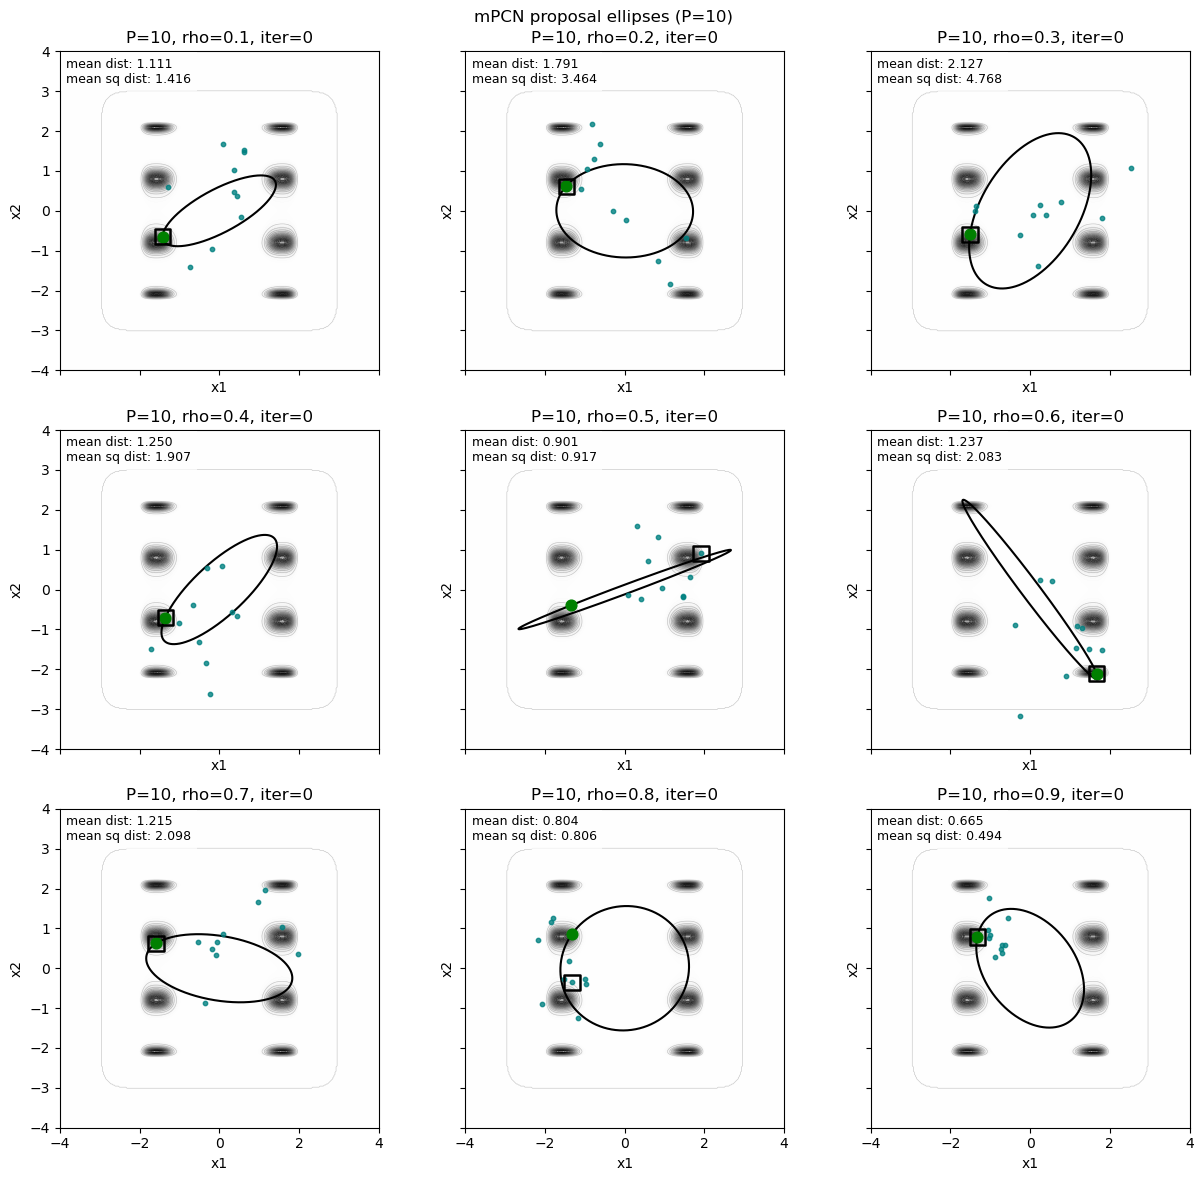

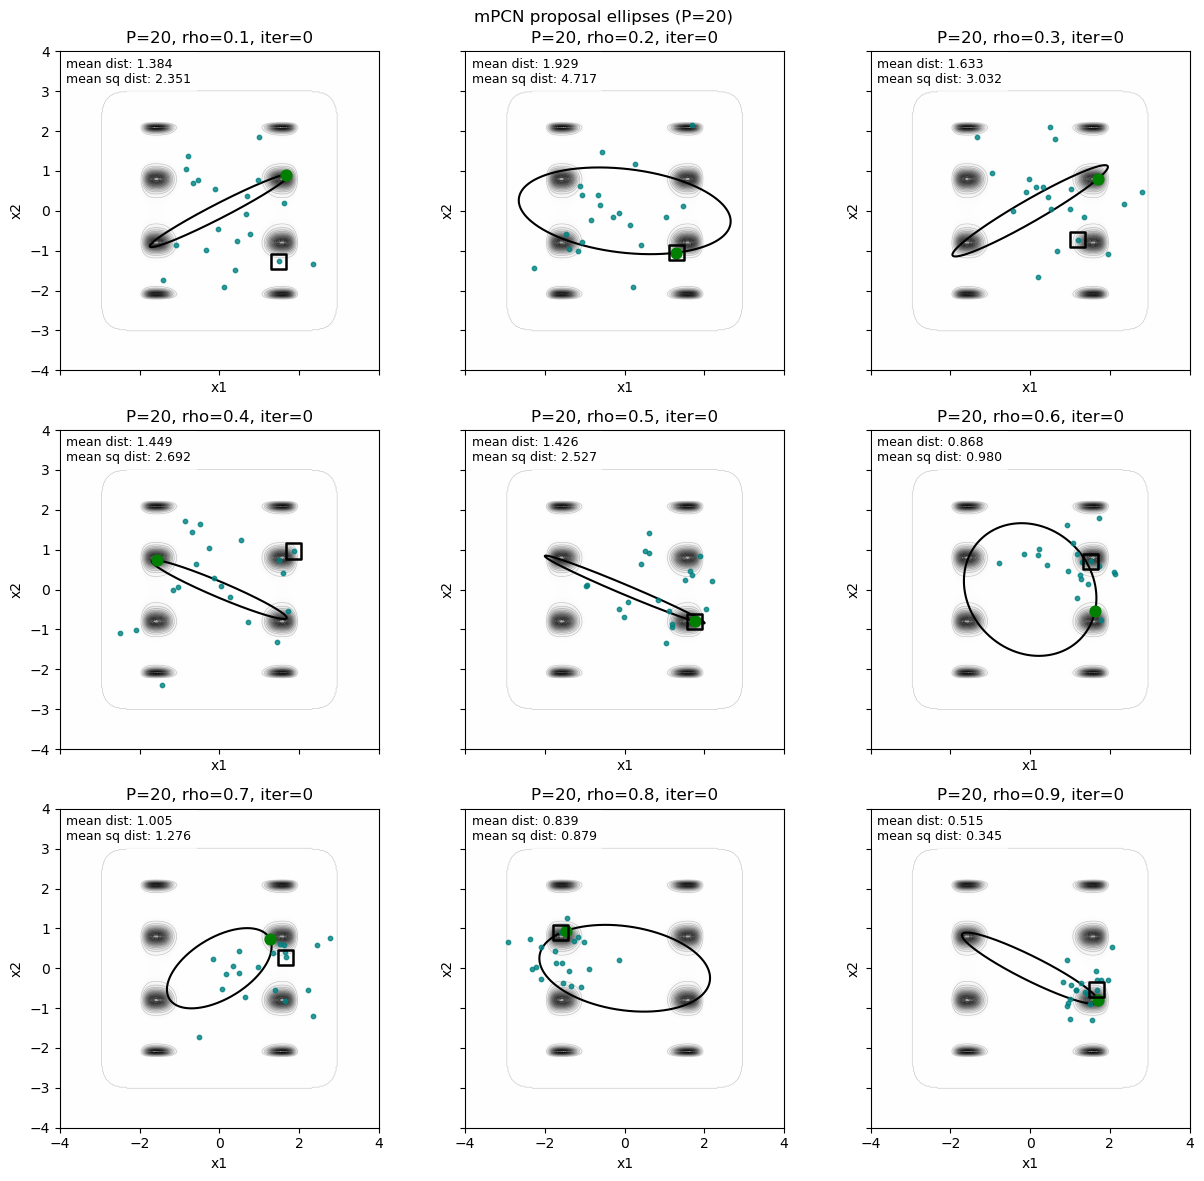

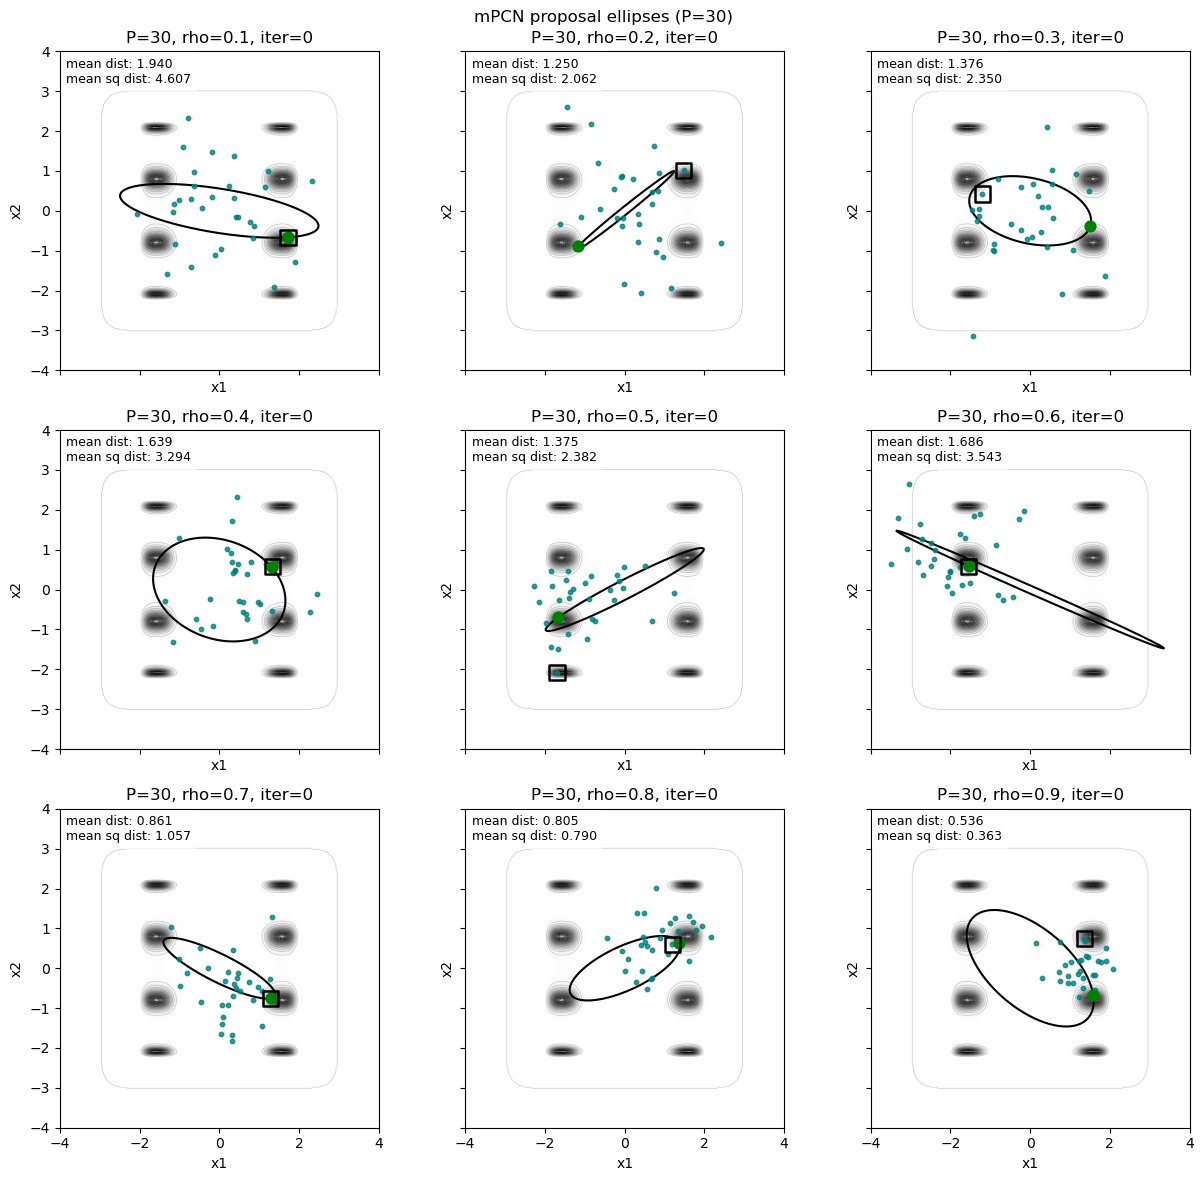

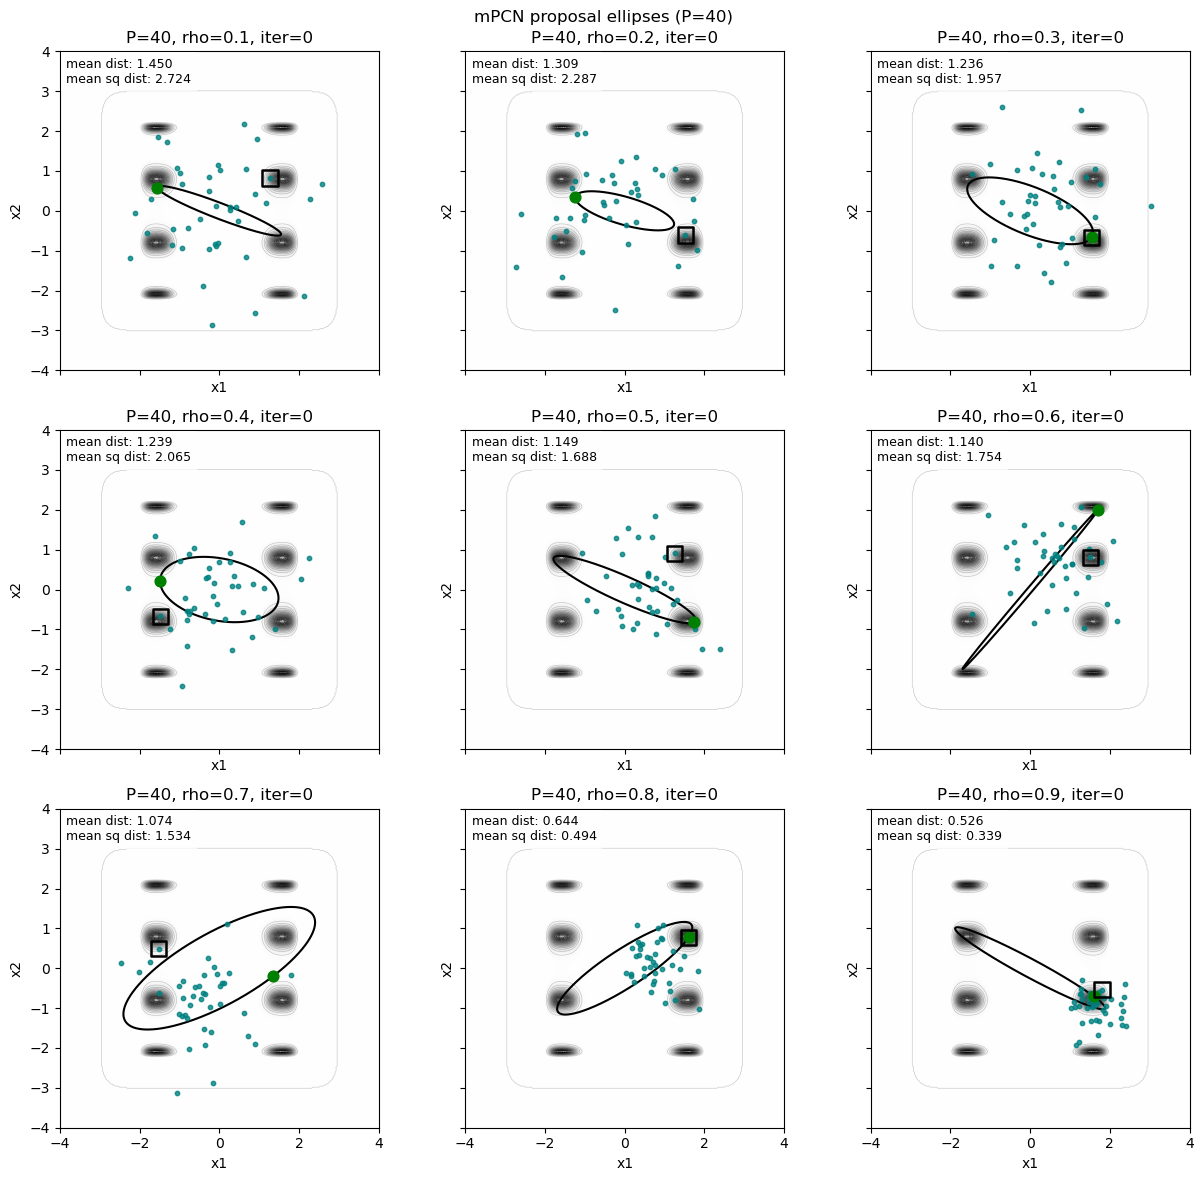

In [8]:
def plot_mpcn_snapshot(ax, snapshot, P, rho, iter_idx):
    mu = problem.prior_mean()
    x = snapshot['x']
    nu_c = snapshot['nu_c']
    props = snapshot['props']
    candidates = snapshot['candidates']
    logy = snapshot['logy']
    accepted_idx = snapshot['accepted_idx']
    mean_dist = snapshot['mean_dist']
    mean_sq_dist = snapshot['mean_sq_dist']
    ellipse = mu + np.cos(theta)[:, None] * (x - mu) + np.sin(theta)[:, None] * nu_c

    ax.contourf(X1, X2, like_density, levels=levels_fill, cmap='Greys', alpha=0.35)
    ax.contour(X1, X2, like_density, levels=levels_line, colors='black', linewidths=0.5, alpha=0.2)
    ax.plot(ellipse[:, 0], ellipse[:, 1], color='black', linewidth=1.5, zorder=2)

    prop_log_like = np.array([problem.log_likelihood(p) for p in props])
    above = prop_log_like >= logy
    ax.scatter(props[~above, 0], props[~above, 1], color='teal', s=10, alpha=0.8, label='props < logy', zorder=2)
    ax.scatter(props[above, 0], props[above, 1], color='teal', s=10, alpha=0.8, label='props >= logy', zorder=2)
    ax.scatter([x[0]], [x[1]], color='green', s=60, marker='o', label='current', zorder=3)
    accepted_point = candidates[accepted_idx]
    ax.scatter([accepted_point[0]], [accepted_point[1]], facecolors='none', edgecolors='black',
               s=120, marker='s', linewidths=1.8, label='accepted', zorder=4)
    ax.text(
        0.02,
        0.98,
        f'mean dist: {mean_dist:.3f}\nmean sq dist: {mean_sq_dist:.3f}',
        transform=ax.transAxes,
        va='top',
        ha='left',
        fontsize=9,
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'),
    )
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.grid(False)
    ax.set_title(f'P={P}, rho={rho:.1f}, iter={iter_idx}')


# Ellipse plots: one figure per P, subplots by rho
n_rho = len(rho_list)
ncols = 3
nrows = int(np.ceil(n_rho / ncols))

for P in P_list:
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 4.0 * nrows), sharex=True, sharey=True)
    axes = np.array(axes).reshape(-1)
    for ax, rho in zip(axes, rho_list):
        snapshot = results['mpcn'][P][rho]['snapshot']
        plot_mpcn_snapshot(ax, snapshot, P, rho, plot_iter)
    for ax in axes[len(rho_list):]:
        ax.axis('off')
    fig.suptitle(f'mPCN proposal ellipses (P={P})')
    fig.tight_layout()
    plt.show()

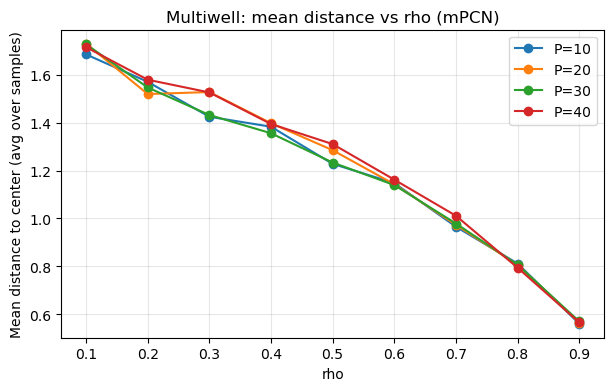

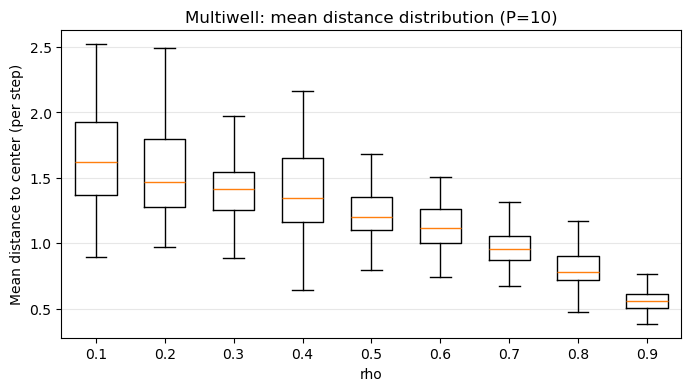

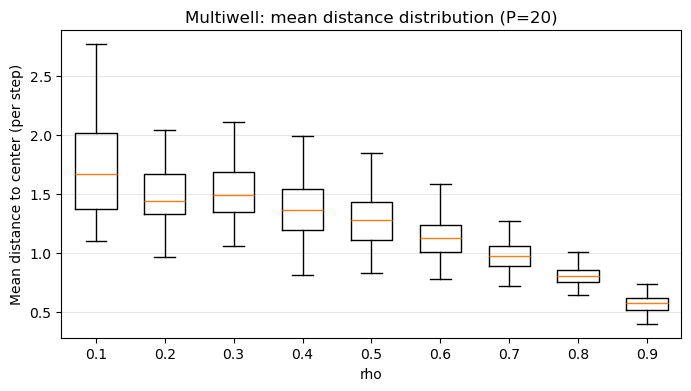

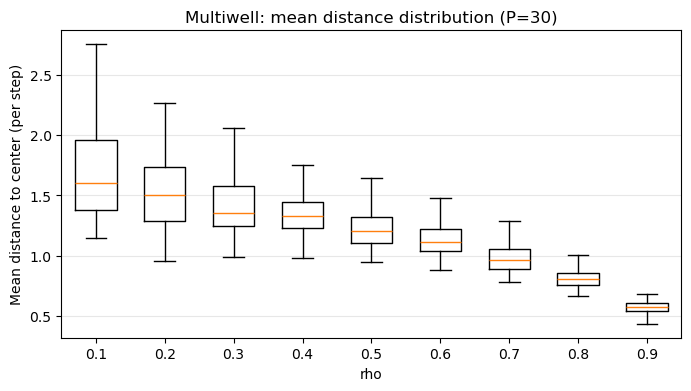

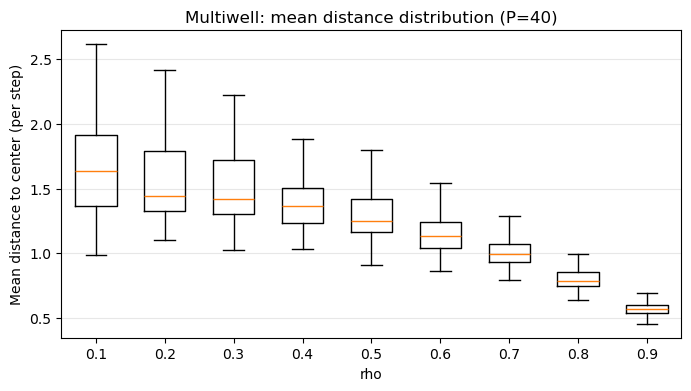

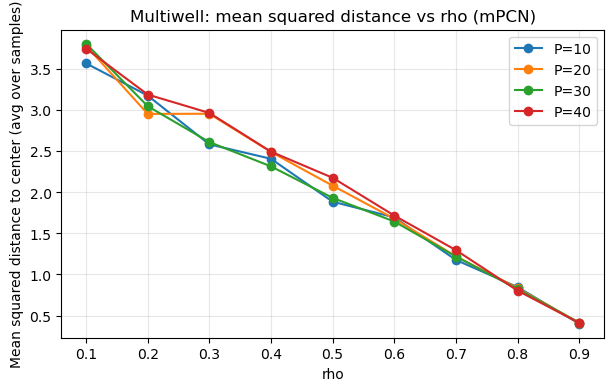

In [ ]:
# Distance summaries vs rho (one curve per P)
P_sorted = sorted(P_list)
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(P_sorted)))
color_by_P = {P: colors[i] for i, P in enumerate(P_sorted)}

fig, ax = plt.subplots(figsize=(7, 4))
for P in P_list:
    dist_vals = [np.mean(results['mpcn'][P][rho]['mean_dist_samples']) for rho in rho_list]
    ax.plot(rho_list, dist_vals, marker='o', color=color_by_P[P], label=f'P={P}')
ax.set_xlabel('rho')
ax.set_ylabel('Mean distance to center (avg over samples)')
ax.set_title('Multiwell: mean distance vs rho (mPCN)')
ax.grid(alpha=0.3)
ax.legend(loc='best')
plt.show()

for P in P_list:
    fig, ax = plt.subplots(figsize=(8, 4))
    dist_samples = [results['mpcn'][P][rho]['mean_dist_samples'] for rho in rho_list]
    ax.boxplot(dist_samples, widths=0.6, showfliers=False)
    ax.set_xticks(np.arange(1, len(rho_list) + 1))
    ax.set_xticklabels([f'{rho:.1f}' for rho in rho_list])
    ax.set_xlabel('rho')
    ax.set_ylabel('Mean distance to center (per step)')
    ax.set_title(f'Multiwell: mean distance distribution (P={P})')
    ax.grid(alpha=0.3, axis='y')
    plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
for P in P_list:
    dist_vals = [np.mean(results['mpcn'][P][rho]['mean_sq_dist_samples']) for rho in rho_list]
    ax.plot(rho_list, dist_vals, marker='o', color=color_by_P[P], label=f'P={P}')
ax.set_xlabel('rho')
ax.set_ylabel('Mean squared distance to center (avg over samples)')
ax.set_title('Multiwell: mean squared distance vs rho (mPCN)')
ax.grid(alpha=0.3)
ax.legend(loc='best')
plt.show()

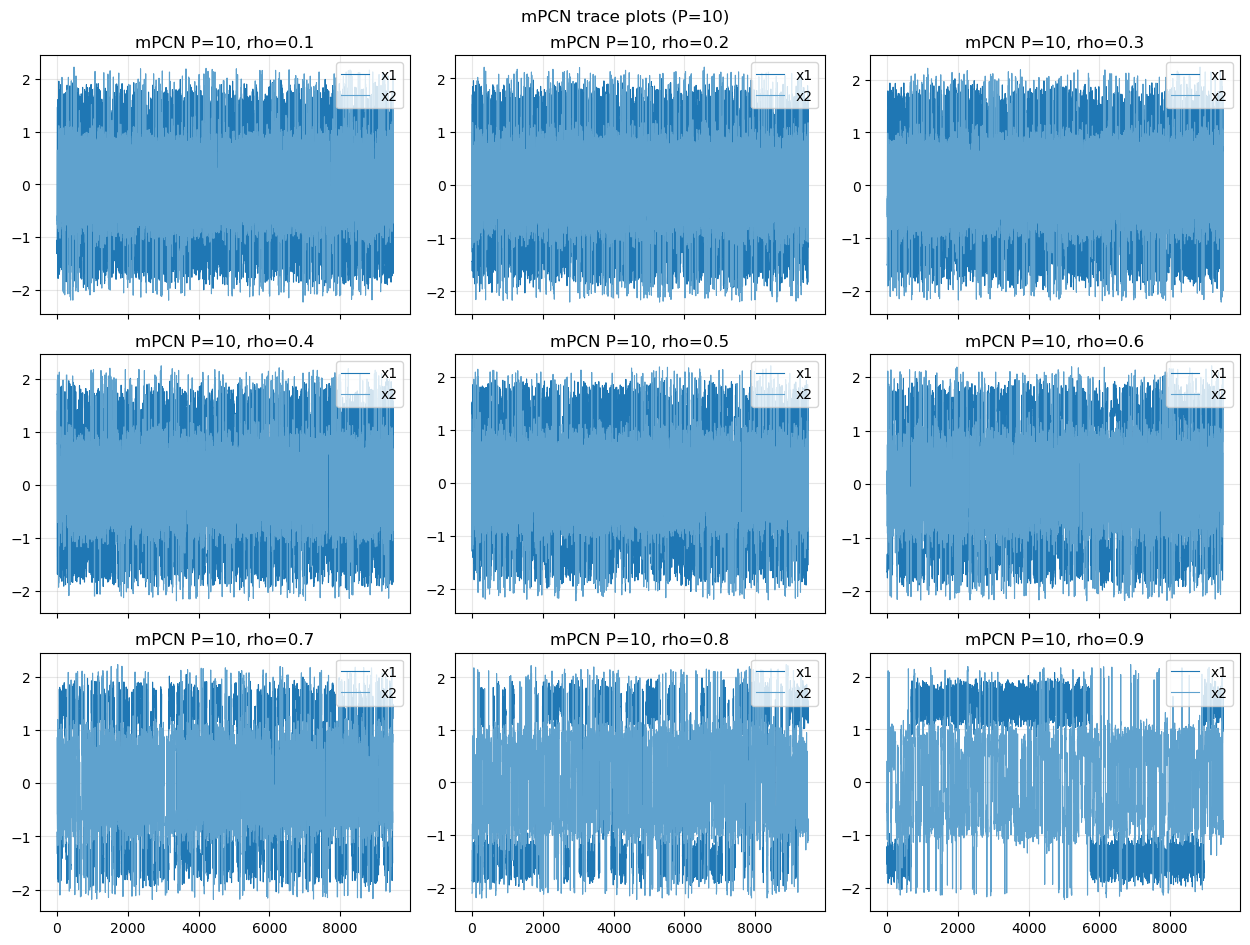

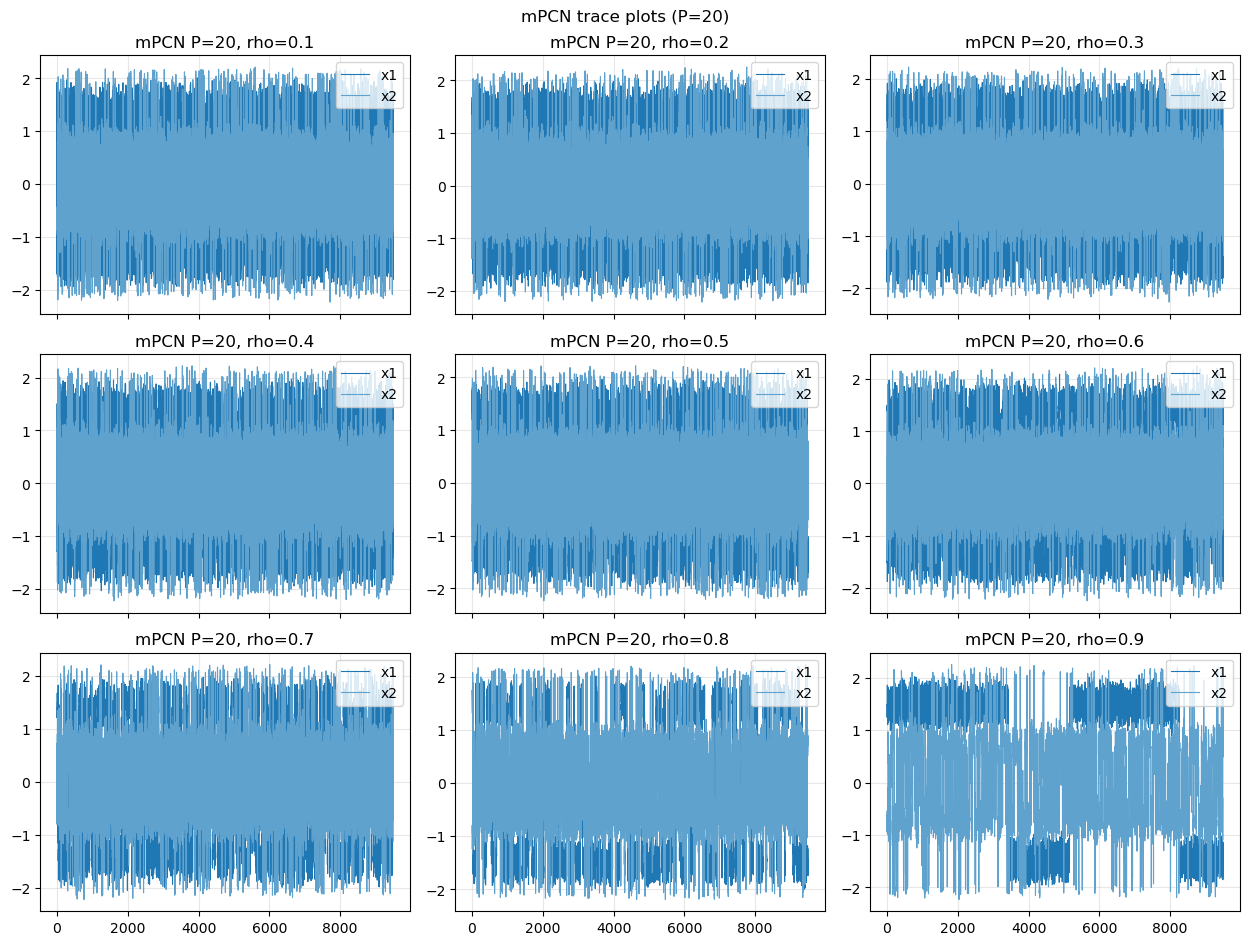

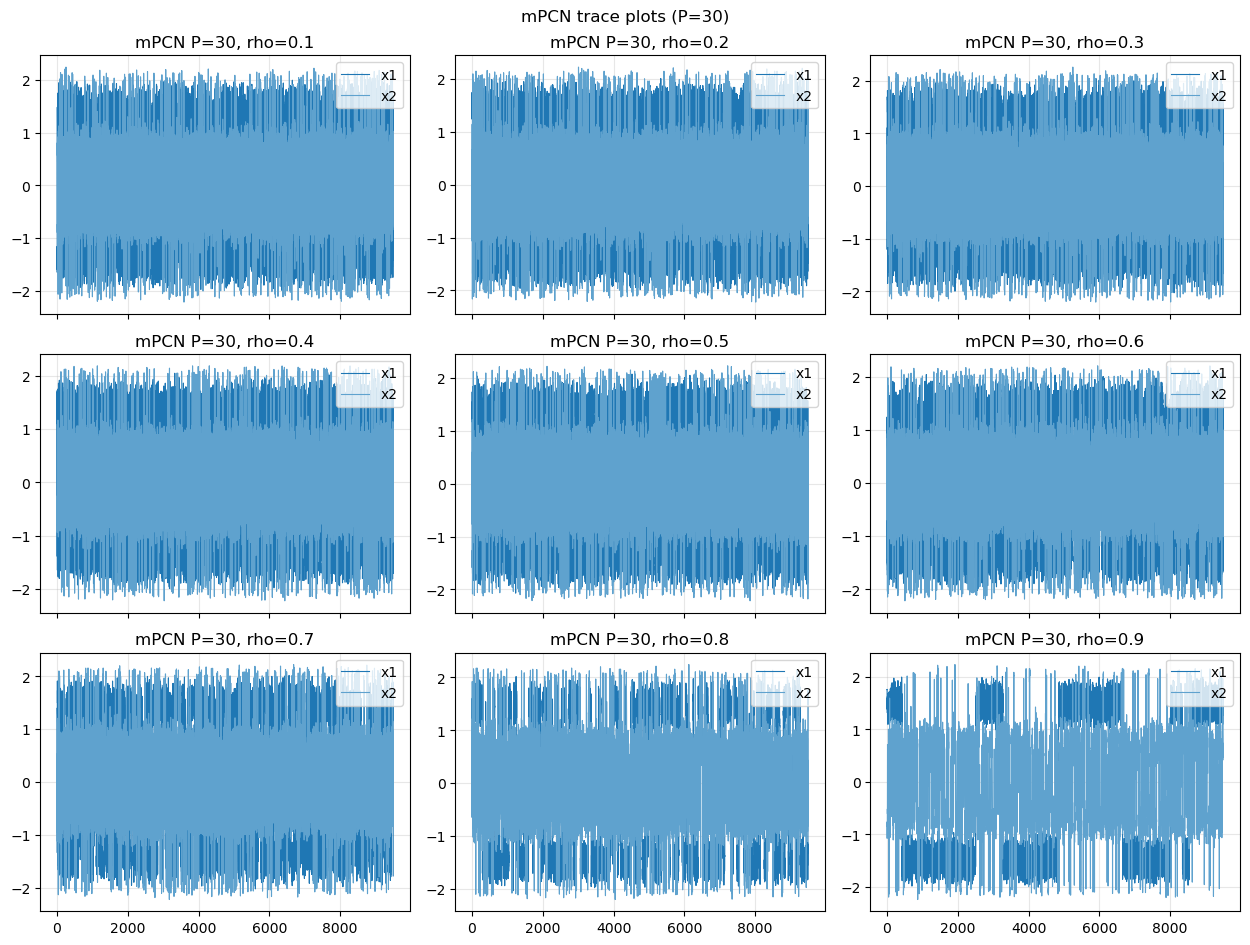

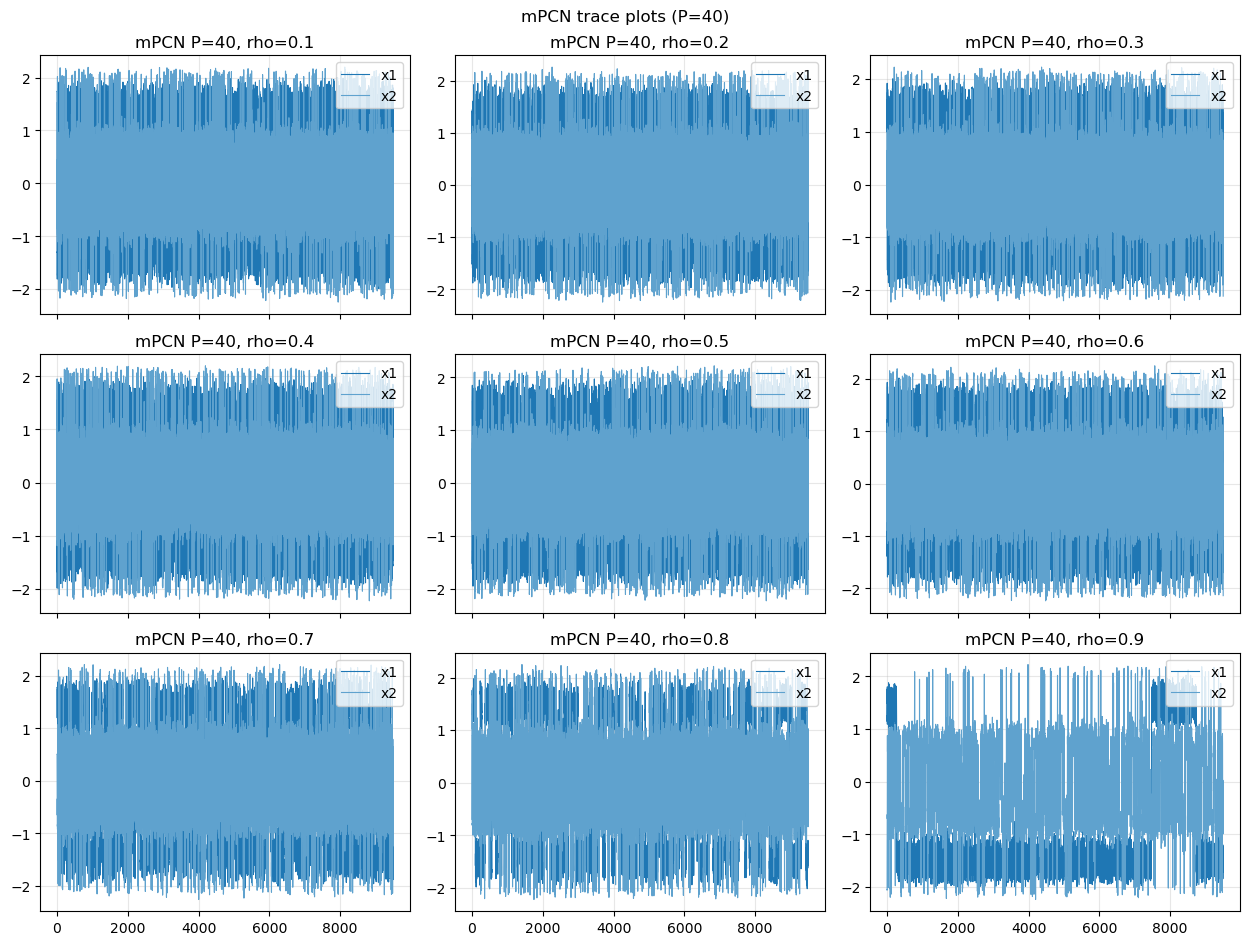

In [10]:
# Trace plots: one figure per P, subplots by rho
n_rho = len(rho_list)
ncols = 3
nrows = int(np.ceil(n_rho / ncols))

for P in P_list:
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.2 * nrows), sharex=True)
    axes = np.array(axes).reshape(-1)
    for ax, rho in zip(axes, rho_list):
        chain = results['mpcn'][P][rho]['chain'][burn_in:]
        ax.plot(chain[:, 0], color='#1f77b4', linewidth=0.8, label='x1')
        ax.plot(chain[:, 1], color='#5fa2ce', linewidth=0.8, label='x2')
        ax.set_title(f'mPCN P={P}, rho={rho:.1f}')
        ax.grid(alpha=0.3)
        ax.legend(loc='upper right')
    for ax in axes[len(rho_list):]:
        ax.axis('off')
    fig.suptitle(f'mPCN trace plots (P={P})')
    fig.tight_layout()
    plt.show()

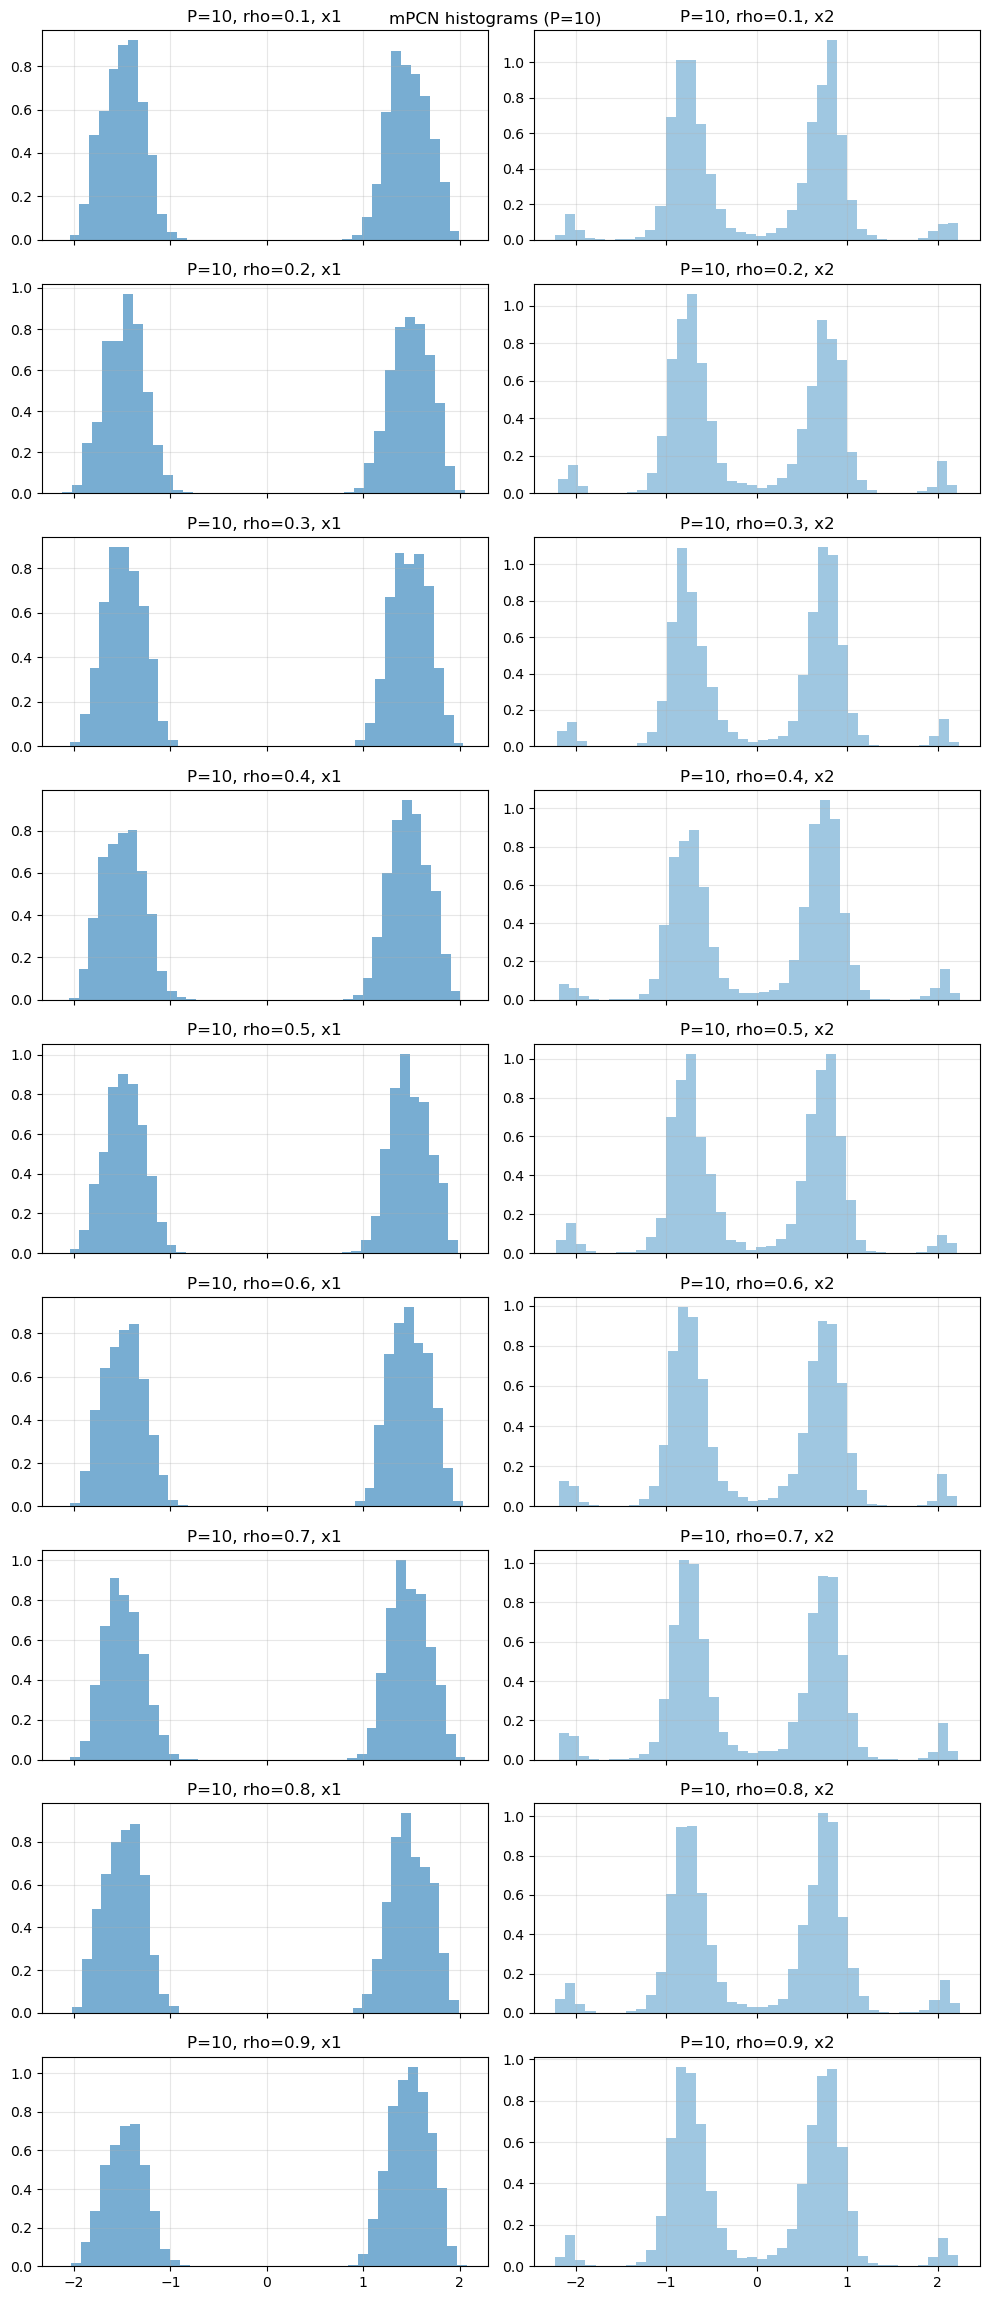

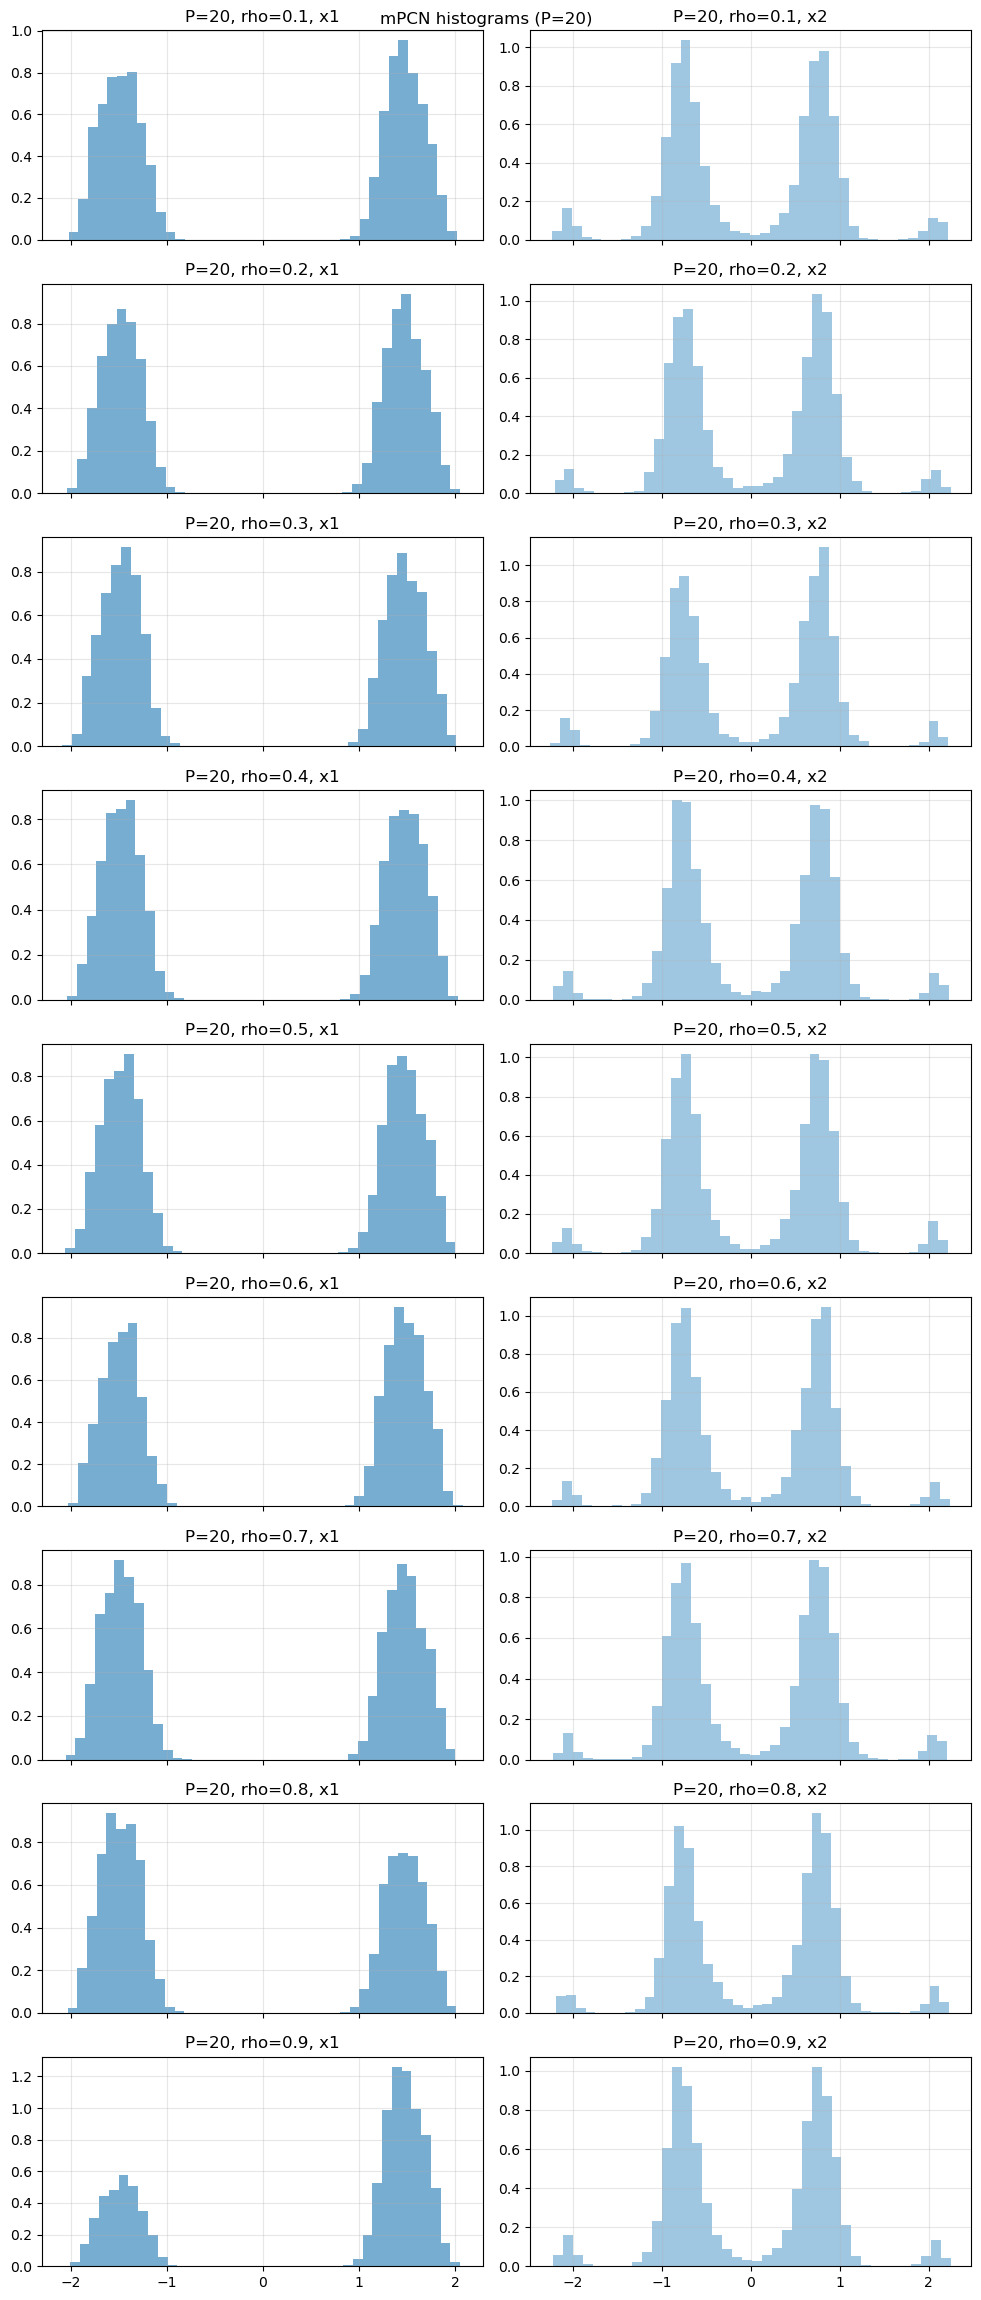

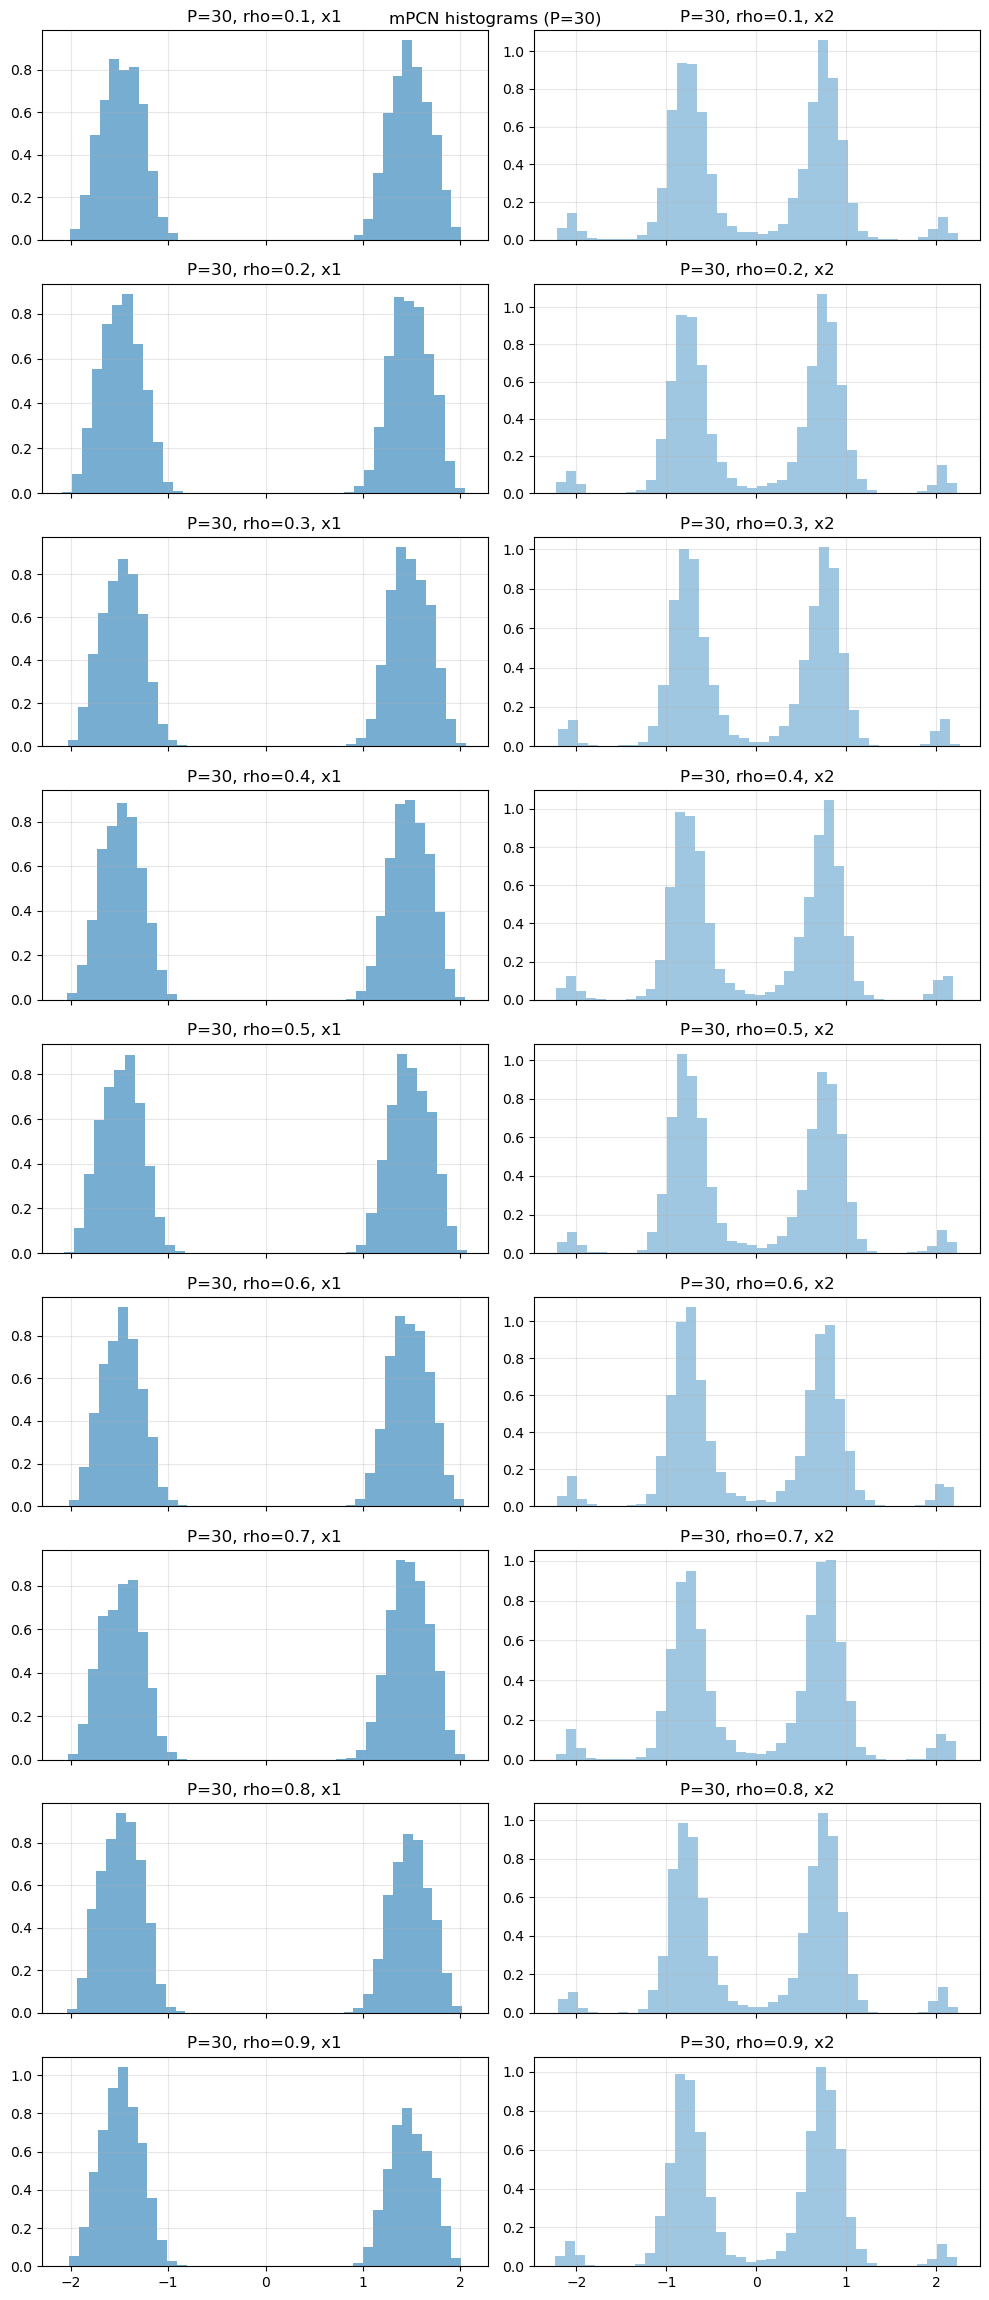

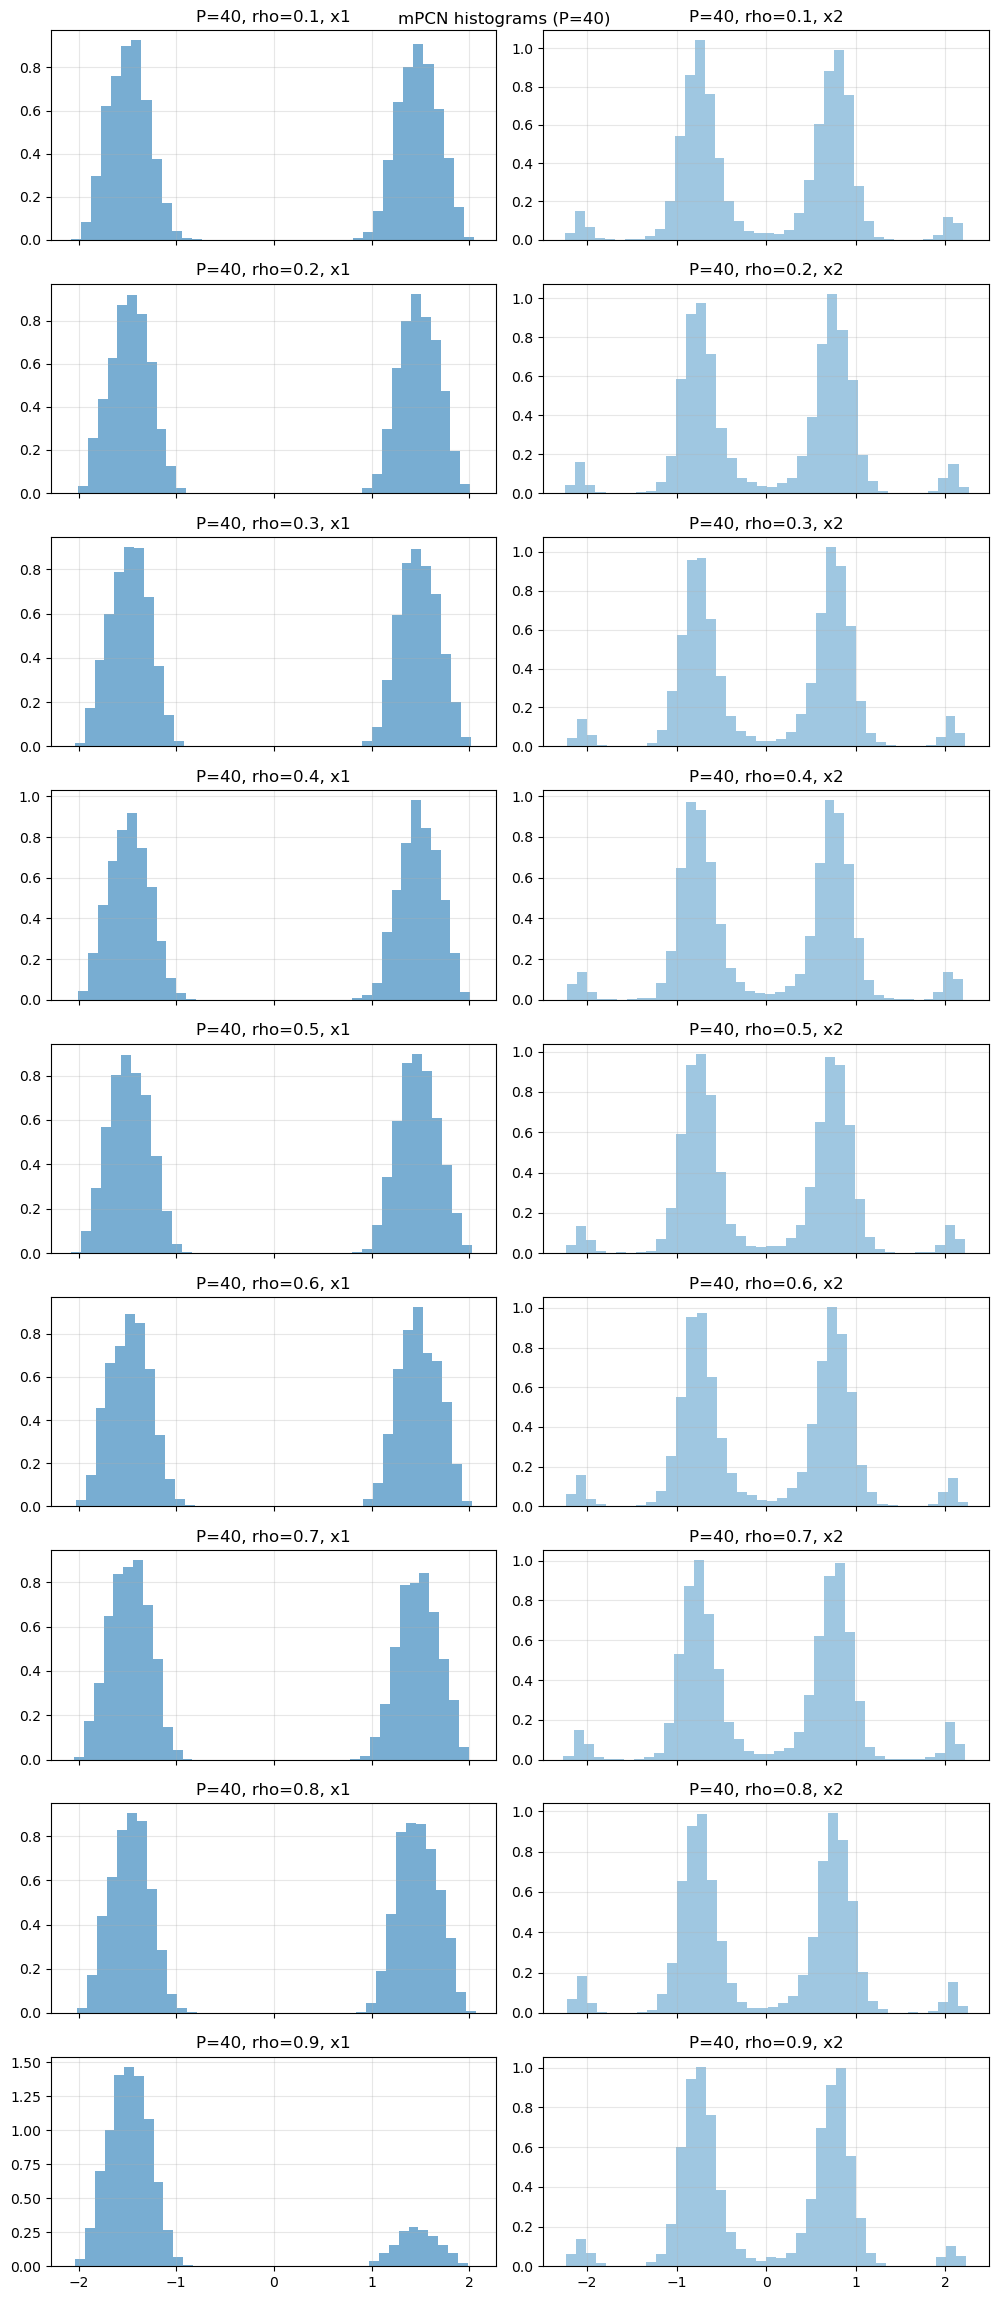

In [11]:
# Histograms: one figure per P, each rho has two subplots (x1, x2)
bins = 40
for P in P_list:
    fig, axes = plt.subplots(len(rho_list), 2, figsize=(10, 2.6 * len(rho_list)), sharex='col')
    for row_idx, rho in enumerate(rho_list):
        chain = results['mpcn'][P][rho]['chain'][burn_in:]
        ax1 = axes[row_idx, 0]
        ax2 = axes[row_idx, 1]
        ax1.hist(chain[:, 0], bins=bins, density=True, color='#1f77b4', alpha=0.6)
        ax2.hist(chain[:, 1], bins=bins, density=True, color='#5fa2ce', alpha=0.6)
        ax1.set_title(f'P={P}, rho={rho:.1f}, x1')
        ax2.set_title(f'P={P}, rho={rho:.1f}, x2')
        ax1.grid(alpha=0.3)
        ax2.grid(alpha=0.3)
    fig.suptitle(f'mPCN histograms (P={P})')
    fig.tight_layout()
    plt.show()

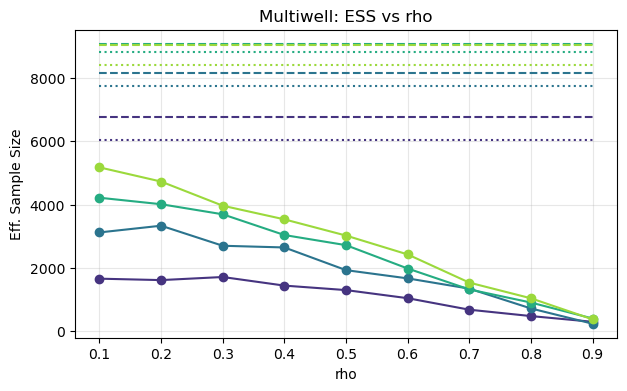

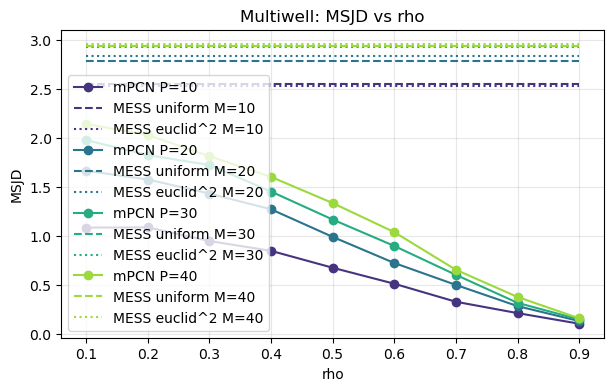

In [17]:
# ESS/MSJD vs rho curves (one line per P)
P_sorted = sorted(P_list)
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(P_sorted)))
color_by_P = {P: colors[i] for i, P in enumerate(P_sorted)}

fig, ax = plt.subplots(figsize=(7, 4))
for P in P_list:
    ess_vals = [results['mpcn'][P][rho]['metrics']['ess_mean'] for rho in rho_list]
    ax.plot(rho_list, ess_vals, marker='o', color=color_by_P[P], label=f'mPCN P={P}')
    mess_uniform = results['mess_uniform'][P]['metrics']['ess_mean']
    mess_euclid = results['mess_euclid_sq'][P]['metrics']['ess_mean']
    ax.plot(rho_list, [mess_uniform] * len(rho_list), linestyle='--', color=color_by_P[P], label=f'MESS uniform M={P}')
    ax.plot(rho_list, [mess_euclid] * len(rho_list), linestyle=':', color=color_by_P[P], label=f'MESS euclid^2 M={P}')
ax.set_xlabel('rho')
ax.set_ylabel('Eff. Sample Size')
ax.set_title('Multiwell: ESS vs rho')
ax.grid(alpha=0.3)
# ax.legend(loc='best')
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
for P in P_list:
    msjd_vals = [results['mpcn'][P][rho]['metrics']['msjd_mean'] for rho in rho_list]
    ax.plot(rho_list, msjd_vals, marker='o', color=color_by_P[P], label=f'mPCN P={P}')
    mess_uniform = results['mess_uniform'][P]['metrics']['msjd_mean']
    mess_euclid = results['mess_euclid_sq'][P]['metrics']['msjd_mean']
    ax.plot(rho_list, [mess_uniform] * len(rho_list), linestyle='--', color=color_by_P[P], label=f'MESS uniform M={P}')
    ax.plot(rho_list, [mess_euclid] * len(rho_list), linestyle=':', color=color_by_P[P], label=f'MESS euclid^2 M={P}')
ax.set_xlabel('rho')
ax.set_ylabel('MSJD')
ax.set_title('Multiwell: MSJD vs rho')
ax.grid(alpha=0.3)
ax.legend(loc='best')
plt.show()

In [13]:
# ESS/MSJD tables (rows=P, columns=rho + MESS)
ess_rows = []
msjd_rows = []
row_labels = []
col_labels = [f'rho={rho:.1f}' for rho in rho_list] + ['mess_uniform', 'mess_euclid_sq']

for P in P_list:
    ess_row = [results['mpcn'][P][rho]['metrics']['ess_mean'] for rho in rho_list]
    msjd_row = [results['mpcn'][P][rho]['metrics']['msjd_mean'] for rho in rho_list]
    ess_row.append(results['mess_uniform'][P]['metrics']['ess_mean'])
    msjd_row.append(results['mess_uniform'][P]['metrics']['msjd_mean'])
    ess_row.append(results['mess_euclid_sq'][P]['metrics']['ess_mean'])
    msjd_row.append(results['mess_euclid_sq'][P]['metrics']['msjd_mean'])
    ess_rows.append(ess_row)
    msjd_rows.append(msjd_row)
    row_labels.append(f'P={P}')

ess_table = pd.DataFrame(ess_rows, index=row_labels, columns=col_labels)
msjd_table = pd.DataFrame(msjd_rows, index=row_labels, columns=col_labels)

print('ESS table (mPCN across rho, MESS in last columns):')
display(ess_table)
print('MSJD table (mPCN across rho, MESS in last columns):')
display(msjd_table)

ESS table (mPCN across rho, MESS in last columns):


,rho=0.1,rho=0.2,rho=0.3,rho=0.4,rho=0.5,rho=0.6,rho=0.7,rho=0.8,rho=0.9,mess_uniform,mess_euclid_sq
P=10,1651.530083,1606.492023,1704.172015,1431.827115,1289.862424,1033.219614,668.983753,467.014537,285.669993,6778.799665,6048.897127
P=20,3115.922650,3328.944999,2693.936837,2640.033843,1921.373765,1660.669395,1335.381973,708.272146,224.878559,8159.720720,7743.778922
P=30,4214.971783,4009.449047,3690.207674,3033.673488,2712.656667,1973.269315,1310.682782,895.095374,390.064988,9092.134753,8822.830188
P=40,5176.723865,4726.784592,3962.161232,3530.033098,3016.469655,2419.106882,1526.327792,1029.928386,363.256526,9058.219930,8423.593157


MSJD table (mPCN across rho, MESS in last columns):


,rho=0.1,rho=0.2,rho=0.3,rho=0.4,rho=0.5,rho=0.6,rho=0.7,rho=0.8,rho=0.9,mess_uniform,mess_euclid_sq
P=10,1.086696,1.088938,0.949828,0.849536,0.676837,0.513318,0.329230,0.213394,0.105008,2.557597,2.534313
P=20,1.668242,1.578123,1.434605,1.274047,0.992051,0.725155,0.501249,0.284667,0.132098,2.786257,2.837155
P=30,1.980310,1.827971,1.726296,1.455191,1.169149,0.899237,0.603948,0.318180,0.148659,2.943284,2.930642
P=40,2.145774,2.032900,1.815815,1.604725,1.337598,1.040304,0.655603,0.377980,0.159939,2.937438,2.965023
